In [85]:
%load_ext autoreload
%autoreload 2
from reward_relative.path_dict_seahorse import path_dictionary as path_dict
from reward_relative import utilities as ut
from reward_relative import plotUtils as pt
from reward_relative import spatial
from reward_relative import placeCellPlot
from reward_relative import dayData as dd
from reward_relative import behavior
import pickle
import dill
import numpy as np
import os 
import matplotlib.pyplot as plt
import TwoPUtils
import protter_functions as pf
from scipy.signal import medfilt
from matplotlib.lines import Line2D
import pandas as pd
import umap
import hdbscan
import importlib
import scipy.interpolate as interp
import protter_functions as pf

import protter_plot_functions as ppf
ppf = importlib.reload(ppf)
from protter_plot_functions import add_hover, add_color_selector, ColorSelector, ColorSelectorV2#, #add_selectors
from claude_test_space import add_selectors
from protter_plot_functions import TrialPlotLinker
import matplotlib.cm as cm
import seaborn as sns
from umap.umap_ import nearest_neighbors


import protter_plot_functions as ppf
ppf = importlib.reload(ppf)
from protter_plot_functions import add_hover, add_color_selector, ColorSelector, ColorSelectorV2#, #add_selectors
from claude_test_space import add_selectors
from protter_plot_functions import TrialPlotLinker
pf = importlib.reload(pf)
import traceback
plt.rcParams['svg.fonttype'] = 'none'

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [86]:
import h5py
file_name = '/data/dave/sosa_data_h5/hdf5_conversion_v2'

f= h5py.File(file_name, "r")

In [138]:
plt.colormaps['winter'](np.linspace(0, 1, 450))

array([[0.        , 0.        , 1.        , 1.        ],
       [0.        , 0.        , 1.        , 1.        ],
       [0.        , 0.00392157, 0.99803922, 1.        ],
       ...,
       [0.        , 0.99607843, 0.50196078, 1.        ],
       [0.        , 1.        , 0.5       , 1.        ],
       [0.        , 1.        , 0.5       , 1.        ]])

In [ ]:
# def create_scatter_color_list(trial_df, neural_bin_centers, cmap1, cmap2 = None):
#     r_loc = pf.get_unique_reward_zones_from_meta(trial_df)

    

#     r_zone_length = int(r_loc[0][1]- r_loc[0][0])
#     r_zone_cmap = plt.cm.Reds_r(np.linspace(0, 1, 2*(r_zone_length)))

#     pos_n_bins = len(neural_bin_centers)
#     n_trials = len(trial_df.trial.unique())
#     position = np.asarray([i for i in range(pos_n_bins)]*n_trials)
#     position[:n_trials*pos_n_bins].shape
#     cmap = plt.cm.winter(np.linspace(0, 1, pos_n_bins))
#     cmap2 = plt.cm.spring(np.linspace(0, 1, pos_n_bins))

#     cmap[r_loc[0][0]:r_loc[0][1],:] = r_zone_cmap[:r_zone_length,:]

#     if len(r_loc) != 1:
#         cmap2[r_loc[1][0]:r_loc[1][1],:] = r_zone_cmap[:r_zone_length,:]



#         c_r1 = [cmap[x] for x in range(len(neural_bin_centers))]
#         c_r2 = [cmap2[x] for x in range(len(neural_bin_centers))]


#         trial_type_bool = trial_df.trial_type=='pre_swap'
#         c = []
#         for t in trial_type_bool:
#             if t:
#                 c+=c_r1
#             else:
#                 c+=c_r2
#     else:
#         c_r1 = [cmap[x] for x in range(len(neural_bin_centers))]
#         c = []
#         for t in range(n_trials):
#             c+=c_r1
         

#     return c

In [151]:
def create_scatter_color_list(trial_df, neural_bin_centers, cmap1_name='viridis', cmap2_name = None):
    r_loc = pf.get_unique_reward_zones_from_meta(trial_df)

    

    r_zone_length = int(r_loc[0][1]- r_loc[0][0])
    r_zone_cmap = plt.cm.Reds_r(np.linspace(0, 1, 2*(r_zone_length)))

    pos_n_bins = len(neural_bin_centers)
    n_trials = len(trial_df.trial.unique())
    position = np.asarray([i for i in range(pos_n_bins)]*n_trials)
    position[:n_trials*pos_n_bins].shape
    cmap = plt.colormaps[cmap1_name](np.linspace(0, 1, pos_n_bins))
    if not cmap2_name is None:  
        cmap2 = plt.colormaps[cmap2_name](np.linspace(0, 1, pos_n_bins))
    else:
        cmap2 = cmap.copy()

    cmap[r_loc[0][0]:r_loc[0][1],:] = r_zone_cmap[:r_zone_length,:]

    if len(r_loc) != 1:
        cmap2[r_loc[1][0]:r_loc[1][1],:] = r_zone_cmap[:r_zone_length,:]



        c_r1 = [cmap[x] for x in range(len(neural_bin_centers))]
        c_r2 = [cmap2[x] for x in range(len(neural_bin_centers))]


        trial_type_bool = trial_df.trial_type=='pre_swap'
        c = []
        for t in trial_type_bool:
            if t:
                c+=c_r1
            else:
                c+=c_r2
    else:
        c_r1 = [cmap[x] for x in range(len(neural_bin_centers))]
        c = []
        for t in range(n_trials):
            c+=c_r1
         

    return c

In [88]:
def trial_df_to_position_df(df, bin_centers):
    expanded = df.loc[df.index.repeat(len(bin_centers))]
    expanded["position"] = np.tile(bin_centers, len(df))
    return expanded

In [89]:
def umap_parameter_search(neural_trials, trial_df, neural_bin_centers, nn_iter = 5, nn_range = [80, 250], md_iter = 3, md_range = [0, 0.5]):
    
    

    fig, axs = plt.subplots(ncols = md_iter, nrows = nn_iter, figsize = (md_iter*5,nn_iter*5), layout = 'constrained')
    neural_trials_reshaped = neural_trials.reshape(neural_trials.shape[0]*neural_trials.shape[1], neural_trials.shape[-1])
    n_preswap = sum(trial_df.trial_type == 'pre_swap')

    c = create_scatter_color_list(trial_df, neural_bin_centers)

    for i, n_neighbor in enumerate(np.linspace(nn_range[0], nn_range[1], nn_iter)):
        for j, min_dist in enumerate(np.linspace(md_range[0], md_range[1], md_iter)):
            
            reducer = umap.UMAP(n_neighbors=int(n_neighbor), min_dist=min_dist)
            
            embedding = reducer.fit_transform(neural_trials_reshaped)

            pre_trials = embedding[:n_preswap*neural_trials.shape[1]]
            post = embedding[n_preswap*neural_trials.shape[1]:]

            axs[i,j].scatter(pre_trials[:,0], pre_trials[:,1], 
                             c = c[:n_preswap*neural_trials.shape[1]], edgecolor = 'blue', alpha = 0.1, label = 'preswap')
            axs[i,j].scatter(post[:,0], post[:,1], 
                             c = c[n_preswap*neural_trials.shape[1]:],edgecolor = 'orange', alpha = 0.1, label = 'postswap')

            omission = np.zeros((embedding.shape[0]), dtype = bool)
            for trial in trial_df.loc[trial_df.omit == True, 'trial'].values:
                omission[int(trial*neural_trials.shape[0]):int(trial*neural_trials.shape[0] + neural_trials.shape[0])] = 1

            axs[i,j].scatter(embedding[omission, 0], embedding[omission, 1], color = 'lightgreen', marker = '.', label = 'omit')
            axs[i,j].legend()
            axs[i,j].set_title(f'nn: {int(n_neighbor)}, md: {min_dist:.3f}')
    return fig

In [90]:
def lick_umap(licks, lick_bins, trial_df):
    
    metadata = trial_df

    features, sorted_meta, sorted_licks = pf.generate_cross_day_features(licks, 
                                                                    metadata, 
                                                                    lick_bins, norm = False, 
                                                                    reward_relative=False
                                                                    )
    feats = features[[c for c in features.columns if not c in [ 'n_licks', ]]]
    feats = np.nan_to_num(feats)

    n_neighbors = max([int(len(licks)/22),4])
    reducer = umap.UMAP(n_neighbors=n_neighbors, min_dist=0.0, )

    transform = reducer.fit_transform(feats)

    min_samples = 3
    min_cluster_size = 3
    new_labels = hdbscan.HDBSCAN(
        min_samples=min_samples,
        min_cluster_size=min_cluster_size,

    ).fit_predict(transform)


    metadata = sorted_meta.copy()
    metadata['hdb_labels'] = new_labels

    return metadata, transform

In [91]:
def plot_lick_clusters(licks, trial_df, labeled_meta):

    labels = labeled_meta.hdb_labels.unique()

    ncols = 3
    nrows = int(np.ceil( (len(labels)+1) /ncols))
    fig, axs = plt.subplots(ncols = ncols, nrows = nrows, figsize = (5*ncols, 9*nrows))

    ppf.plot_raster_from_licks(licks, 
                        trial_df, ax = axs.ravel()[0] )

    axs.ravel()[0].set_title('all trials')
    for ax, label in zip(axs.ravel()[1:], labels):
        hd5_df_from_label = trial_df.loc[trial_df.idx.isin(labeled_meta.loc[labeled_meta.hdb_labels == label, 'idx'])] 
        lick_from_label = pf.get_data_trials_by_idx(licks, trial_df, labeled_meta.loc[labeled_meta.hdb_labels == label, 'idx'])
        if len(hd5_df_from_label) == 1:
            lick_from_label = [lick_from_label]
        ppf.plot_raster_from_licks(lick_from_label, hd5_df_from_label, ax)
        ax.set_title(label)

    return fig


In [92]:
def plot_neural_umap_with_lick_clusters(neural_data, licks, labeled_meta,  
                                        neural_bin_centers, speeds,  
                                        n_neighbors = 150, min_dist = 0.05,  speed_bins = np.arange(5, 455, 10)):
    neural_trials_reshaped = neural_data.reshape(neural_data.shape[0]*neural_data.shape[1], neural_data.shape[-1])

    neural_embedding = umap.UMAP(n_neighbors= n_neighbors, min_dist=min_dist).fit_transform(neural_trials_reshaped)

    scatter_meta = trial_df_to_position_df(labeled_meta, neural_bin_centers)
    n_labels = len(scatter_meta.hdb_labels.unique())


    fig, axs = plt.subplots(nrows = n_labels, ncols = 3, figsize = (3.5*3, 3.5*n_labels),layout="constrained")



    trial_cmap = sns.color_palette("tab10", as_cmap = True)

    for i, label in enumerate(scatter_meta.hdb_labels.unique()):

        dat = neural_embedding[scatter_meta.hdb_labels == label]
        dat_n = neural_embedding[scatter_meta.hdb_labels != label]
        axs[i,0].scatter(dat_n[:,0], dat_n[:,1], alpha = 0.05, color = 'black')

        compare_idxs = labeled_meta.loc[(labeled_meta.hdb_labels==label), 'idx'].values
        compare_meta = labeled_meta.loc[(labeled_meta.hdb_labels==label)]

        compare_licks = pf.get_data_trials_by_idx(licks, labeled_meta, compare_idxs)


        linker = ppf.ColorLinker('trial')
        categorical_cmap = {unique:trial_cmap(i % trial_cmap.N) for i, unique in enumerate(compare_meta.trial.values)} #keep this to pass to other plot objects
        linker.set_categorical(categorical_cmap, 'trial')
        
        if len(compare_meta) == 1:
            compare_licks = [compare_licks]
        v = ppf.plot_raster_from_licks(compare_licks, 
                        compare_meta,ax = axs[i,1], edge_colorby = 'trial', edgecm = linker)

        
        try:
            c = create_scatter_color_list(compare_meta, neural_bin_centers)
        except:
            print(compare_meta)
        

        trial_colors = [trial_cmap(i % trial_cmap.N) for i, unique in enumerate(compare_meta.trial.values)]
        
        facecolors = []
        for color, _ in zip(trial_colors, range(len(compare_meta))):
            facecolors += [color]*len(neural_bin_centers)

        axs[i,0].scatter(dat[:,0], dat[:,1], facecolor= c, edgecolor = facecolors)

        speeds_from_label = pf.get_data_trials_by_idx(speeds, labeled_meta, compare_idxs)

        #in case the label returns just one trial
        if len(speeds_from_label) == max(speed_bins.shape):
            speeds_from_label = [speeds_from_label]

        for j, trial in enumerate(speeds_from_label):
            
           
            axs[i, -1].plot(speed_bins, trial, color = trial_colors[j])

        axs[i,1].set_title(label)


        
        

    return fig

In [488]:
def plot_neural_embeddings_with_lick_clusters(neural_embedding, licks, labeled_meta,  
                                        neural_bin_centers, speeds, scatter_meta = None, speed_bins = np.arange(5, 455, 10),
                                        cmap1_name = 'viridis', cmap2_name = None, trial_list = None):


    if scatter_meta is None:
        scatter_meta = trial_df_to_position_df(labeled_meta, neural_bin_centers)
    n_labels = len(scatter_meta.hdb_labels.unique())


    

    rzones = pf.get_unique_reward_zones_from_meta(labeled_meta)

    trial_cmap = sns.color_palette("tab10", as_cmap = True)
    if trial_list is None:
        fig, axs = plt.subplots(nrows = n_labels, ncols = 3, figsize = (3.5*3, 3.5*n_labels),layout="constrained")
        for i, label in enumerate(scatter_meta.hdb_labels.unique()):

            dat = neural_embedding[scatter_meta.hdb_labels == label]
            dat_n = neural_embedding[scatter_meta.hdb_labels != label]
            axs[i,0].scatter(dat_n[:,0], dat_n[:,1], alpha = 0.05, color = 'black')

            compare_idxs = labeled_meta.loc[(labeled_meta.hdb_labels==label), 'idx'].values
            compare_meta = labeled_meta.loc[(labeled_meta.hdb_labels==label)]

            compare_licks = pf.get_data_trials_by_idx(licks, labeled_meta, compare_idxs)


            linker = ppf.ColorLinker('trial')
            categorical_cmap = {unique:trial_cmap(i % trial_cmap.N) for i, unique in enumerate(compare_meta.trial.values)} #keep this to pass to other plot objects
            linker.set_categorical(categorical_cmap, 'trial')
            
            if len(compare_meta) == 1:
                compare_licks = [compare_licks]
            v = ppf.plot_raster_from_licks(compare_licks, 
                            compare_meta,ax = axs[i,1], edge_colorby = 'trial', edgecm = linker)

            
            try:
                c = create_scatter_color_list(compare_meta, neural_bin_centers, cmap1_name=cmap1_name, cmap2_name=cmap2_name)
            except:
                # print(compare_meta)
                traceback.print_exc()
            

            trial_colors = [trial_cmap(i % trial_cmap.N) for i, unique in enumerate(compare_meta.trial.values)]
            
            facecolors = []
            for color, _ in zip(trial_colors, range(len(compare_meta))):
                facecolors += [color]*len(neural_bin_centers)

            axs[i,0].scatter(dat[:,0], dat[:,1], facecolor= c, edgecolor = facecolors)

            speeds_from_label = pf.get_data_trials_by_idx(speeds, labeled_meta, compare_idxs)

            #in case the label returns just one trial
            if len(speeds_from_label) == max(speed_bins.shape):
                speeds_from_label = [speeds_from_label]

            for rzone in rzones:
                    axs[i,-1].axvspan(xmin = rzone[0], xmax = rzone[1], color = 'red', alpha = 0.2)

            for j, trial in enumerate(speeds_from_label):
                
            
                axs[i, -1].plot(speed_bins, trial, color = trial_colors[j])

            axs[i,1].set_title(label)
            axs[i,-1].set_ylabel('speed (cm/s)')
            axs[i,-1].set_xlabel('position')
        


        
        

    return fig

In [486]:

animals = f.keys()

for animal in animals:
    days = sorted(f[animal].keys(), key=int)

    for i, day in enumerate(days):

        if not os.path.isfile(f'/data/dave/sosa_data_h5/umap_parameter_search_output/neural_umap_with_lick_cluster/{animal}_{day}_neural_vs_licks.png'):

            print(f'{animal}: {day} ({i+1}/{len(days)})')
            licks = f[animal][day]['lick_data']['smoothed_licks'][:]
            lick_bins = f[animal][day]['lick_data']['bin_center'][:]
            neural_trials_raw = f[animal][day]['neural_events_trial_matrix'][:]
            speeds = f[animal][day]['speed']['speed'][:]
            neural_trials = pf.tm_zscore(neural_trials_raw)


            neural_bins = np.arange(0.5, 450.5, 1)
            df = pf.recreate_trial_meta_df(f[animal][day]['trial_metadata'])

            labeled_meta, lick_transform = lick_umap(licks, lick_bins, df)
            try:
                fig = plot_lick_clusters(licks, labeled_meta, labeled_meta)
                fig.suptitle(f'{animal}: {day}')
                fig.savefig(f'/data/dave/sosa_data_h5/umap_parameter_search_output/lick_umap_plots/{animal}_{day}_lick_clusters.png', dpi = 300)
                plt.close(fig)
            except:
                print(f'{animal} {day} lick clusters failed')
                traceback.print_exc()
            # try:
            #     fig = umap_parameter_search(neural_trials,  labeled_meta, neural_bins)
            #     fig.suptitle(f'{animal}: {day}')
            #     fig.savefig(f'/data/dave/sosa_data_h5/umap_parameter_search_output/neural_umap_parameter_search/{animal}_{day}_umap_parameters.png', dpi = 200)
            #     plt.close(fig)
            # except:
        
            #     print(f'{animal} {day} umap parameter search failed')
            #     traceback.print_exc()

            try:
                fig = plot_neural_umap_with_lick_clusters(neural_trials, licks, labeled_meta, neural_bins, speeds)
                fig.suptitle(f'{animal}: {day}')
                fig.savefig(f'/data/dave/sosa_data_h5/umap_parameter_search_output/neural_umap_with_lick_cluster/{animal}_{day}_neural_vs_licks.png', dpi = 200)
                plt.close(fig)

            except:
                    print(f'{animal} {day} umap to lick cluster overlay failed')
                    traceback.print_exc()










In [94]:
n_neighbors = 125
min_dist = 0
random_state = 10

file_name = f'/data/dave/sosa_data_h5/embeddings_nn_{n_neighbors}_md_{min_dist}_rs_{random_state}'


if os.path.exists(file_name):
    response = input(f'file already exists! want to overwrite? (y)')
    if not response.lower() == 'y':
        raise FileExistsError('not going to overwrite your db, sorry!')




with h5py.File(file_name, "w") as f_embeddings:
    animal_groups = {animal: f_embeddings.create_group(animal) for animal in animals}
    for animal in animals:
        days = sorted(f[animal].keys(), key=int)

        for i, day in enumerate(days):
            print(f'{animal}: {day} ({i+1}/{len(days)})')
            licks = f[animal][day]['lick_data']['smoothed_licks'][:]
            lick_bins = f[animal][day]['lick_data']['bin_center'][:]
            neural_trials_raw = f[animal][day]['neural_events_trial_matrix'][:]
            speeds = f[animal][day]['speed']['speed'][:]
            neural_data = pf.tm_zscore(neural_trials_raw)


            neural_bins = np.arange(0.5, 450.5, 1)
            df = pf.recreate_trial_meta_df(f[animal][day]['trial_metadata'])

            labeled_meta, lick_transform = lick_umap(licks, lick_bins, df)

            neural_trials_reshaped = neural_data.reshape(neural_data.shape[0]*neural_data.shape[1], neural_data.shape[-1])
            
            neural_embedding = umap.UMAP(n_neighbors= n_neighbors, min_dist=min_dist, random_state = random_state).fit_transform(neural_trials_reshaped)


            # ------------------ save to hdf file -----------------------

            today = animal_groups[animal].create_group(str(day))
            today.create_dataset('umap_embedding', data = neural_embedding)
            
            meta = today.create_group('labeled_lick_metadata')

            for col in labeled_meta.columns:
                data = labeled_meta[col].values

                meta.create_dataset(col, data = data)



FileExistsError: not going to overwrite your db, sorry!

In [ ]:
file_name = f'/data/dave/sosa_data_h5/embeddings_nn_125_md_0_rs_10'


In [700]:
f_embed = h5py.File(file_name, "r") 

In [701]:
animal = 'GCAMP14'
day = '12'
f_embed[animal][day].keys()
animal_day_group = f_embed[animal][day]

In [702]:
trial_df = pf.recreate_trial_meta_df(animal_day_group['labeled_lick_metadata'])

In [703]:
neural_trials = f[animal][day]['neural_events_trial_matrix']
licks = f[animal][day]['lick_data']['smoothed_licks'][:]
lick_bins = f[animal][day]['lick_data']['bin_center'][:]
speeds = f[animal][day]['speed']['speed'][:]

In [704]:
scatter_df = trial_df_to_position_df(trial_df, neural_bins)

In [705]:
c = create_scatter_color_list(trial_df, neural_bins)

In [706]:
scatter_data = animal_day_group['umap_embedding']

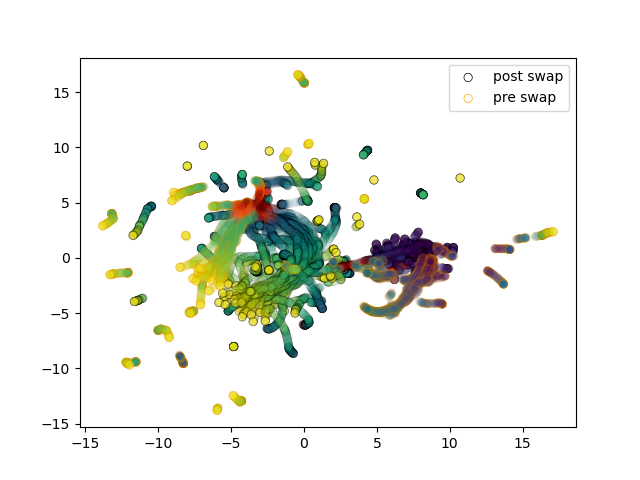

In [707]:
%matplotlib widget
fig, ax = plt.subplots()
pre = (scatter_df.trial_type == 'pre_swap').values
post = (scatter_df.trial_type == 'post_swap').values
c_arr = np.asarray(c)
ax.scatter(scatter_data[post,0], scatter_data[post,1], facecolor = c_arr[post], edgecolors='black', linewidth = 0.5, alpha = 0.05)
ax.scatter(scatter_data[pre,0], scatter_data[pre,1], facecolor = c_arr[pre], edgecolors='orange', linewidth = 0.5, alpha = 0.05)

ax.scatter([], [], facecolor = 'None', edgecolors='black', linewidth = 0.5, label = 'post swap')
ax.scatter([], [], facecolor = 'None', edgecolors='orange', linewidth = 0.5, label = 'pre swap')

ax.legend()

# fig.savefig('GCAMP14_manifold_example.svg')

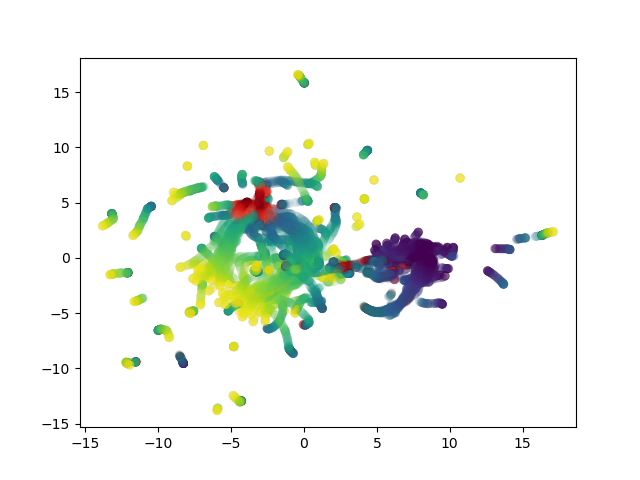

In [708]:
%matplotlib widget
fig, ax = plt.subplots()
pre = (scatter_df.trial_type == 'pre_swap').values
post = (scatter_df.trial_type == 'post_swap').values
c_arr = np.asarray(c)
ax.scatter(scatter_data[post,0], scatter_data[post,1], facecolor = c_arr[post], linewidth = 0.5, alpha = 0.05)
ax.scatter(scatter_data[pre,0], scatter_data[pre,1], facecolor = c_arr[pre],linewidth = 0.5, alpha = 0.05)



# fig.savefig('GCAMP14_manifold_example_2.svg')

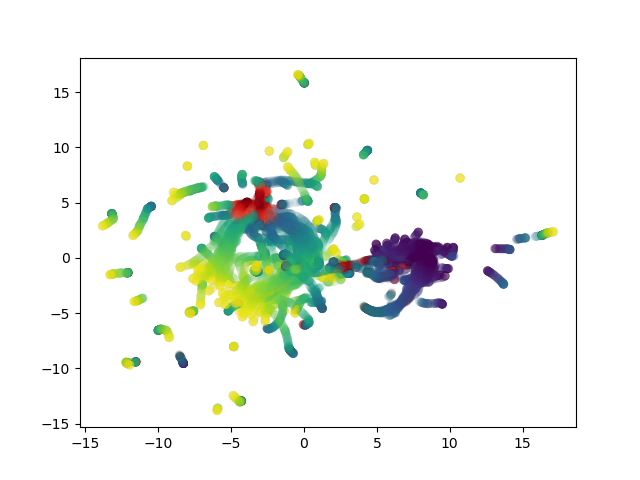

In [709]:
%matplotlib widget
fig, ax = plt.subplots()
pre = (scatter_df.trial_type == 'pre_swap').values
post = (scatter_df.trial_type == 'post_swap').values
c = create_scatter_color_list(trial_df, neural_bins)
c_arr = np.asarray(c)
ax.scatter(scatter_data[post,0], scatter_data[post,1], facecolor = c_arr[post], linewidth = 0.5, alpha = 0.05)
ax.scatter(scatter_data[pre,0], scatter_data[pre,1], facecolor = c_arr[pre],linewidth = 0.5, alpha = 0.05)



# fig.savefig('GCAMP14_manifold_example_3.svg')

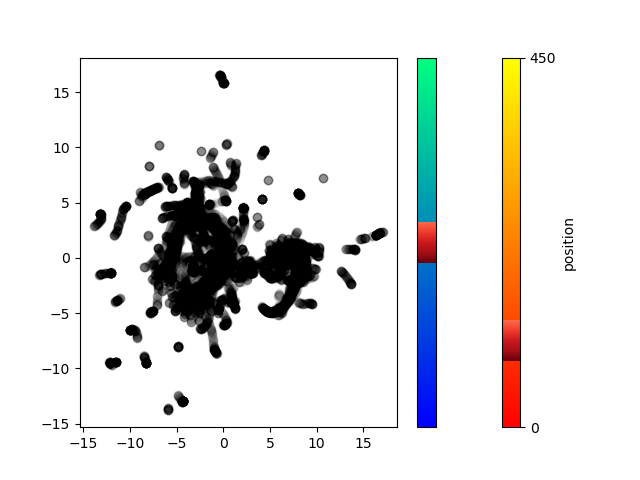

In [710]:
%matplotlib widget

from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize, ListedColormap

fig, ax = plt.subplots()
pre = (scatter_df.trial_type == 'pre_swap').values
post = (scatter_df.trial_type == 'post_swap').values
c = create_scatter_color_list(trial_df, neural_bins, cmap1_name='winter', cmap2_name = 'autumn')
c_arr = np.asarray(c)
scatter0 = ax.scatter(scatter_data[:,0], scatter_data[:,1], facecolor = 'black',  alpha = 0.025)

# scatter1 = ax.scatter(scatter_data[post,0], scatter_data[post,1], facecolor = c_arr[post], linewidth = 0.5, alpha = 0.05)
# scatter2 = ax.scatter(scatter_data[pre,0], scatter_data[pre,1], facecolor = c_arr[pre],linewidth = 0.5, alpha = 0.05)


# scatter0 = ax.scatter(scatter_data[post,0], scatter_data[post,1], facecolor = 'black',  alpha = 0.025)

# scatter1 = ax.scatter(scatter_data[post,0], scatter_data[post,1], facecolor = c_arr[post], linewidth = 0.5, alpha = 0.05)
# scatter2 = ax.scatter(scatter_data[pre,0], scatter_data[pre,1], facecolor = c_arr[pre],linewidth = 0.5, alpha = 0.05)


vmin, vmax = [0, 450]

cb = fig.colorbar(
    ScalarMappable(norm=Normalize(vmin, vmax), cmap=ListedColormap(c_arr[-450:])),
    ax=ax,
    ticks=[vmin, vmax], 
    label = 'position'
                       
)


cb = fig.colorbar(
    ScalarMappable(norm=Normalize(vmin, vmax), cmap=ListedColormap(c_arr[0:450])),
    ax=ax,
    ticks=[], 
                          
)






fig.savefig(f'{animal}_{day}_manifold_example_4_none.png')

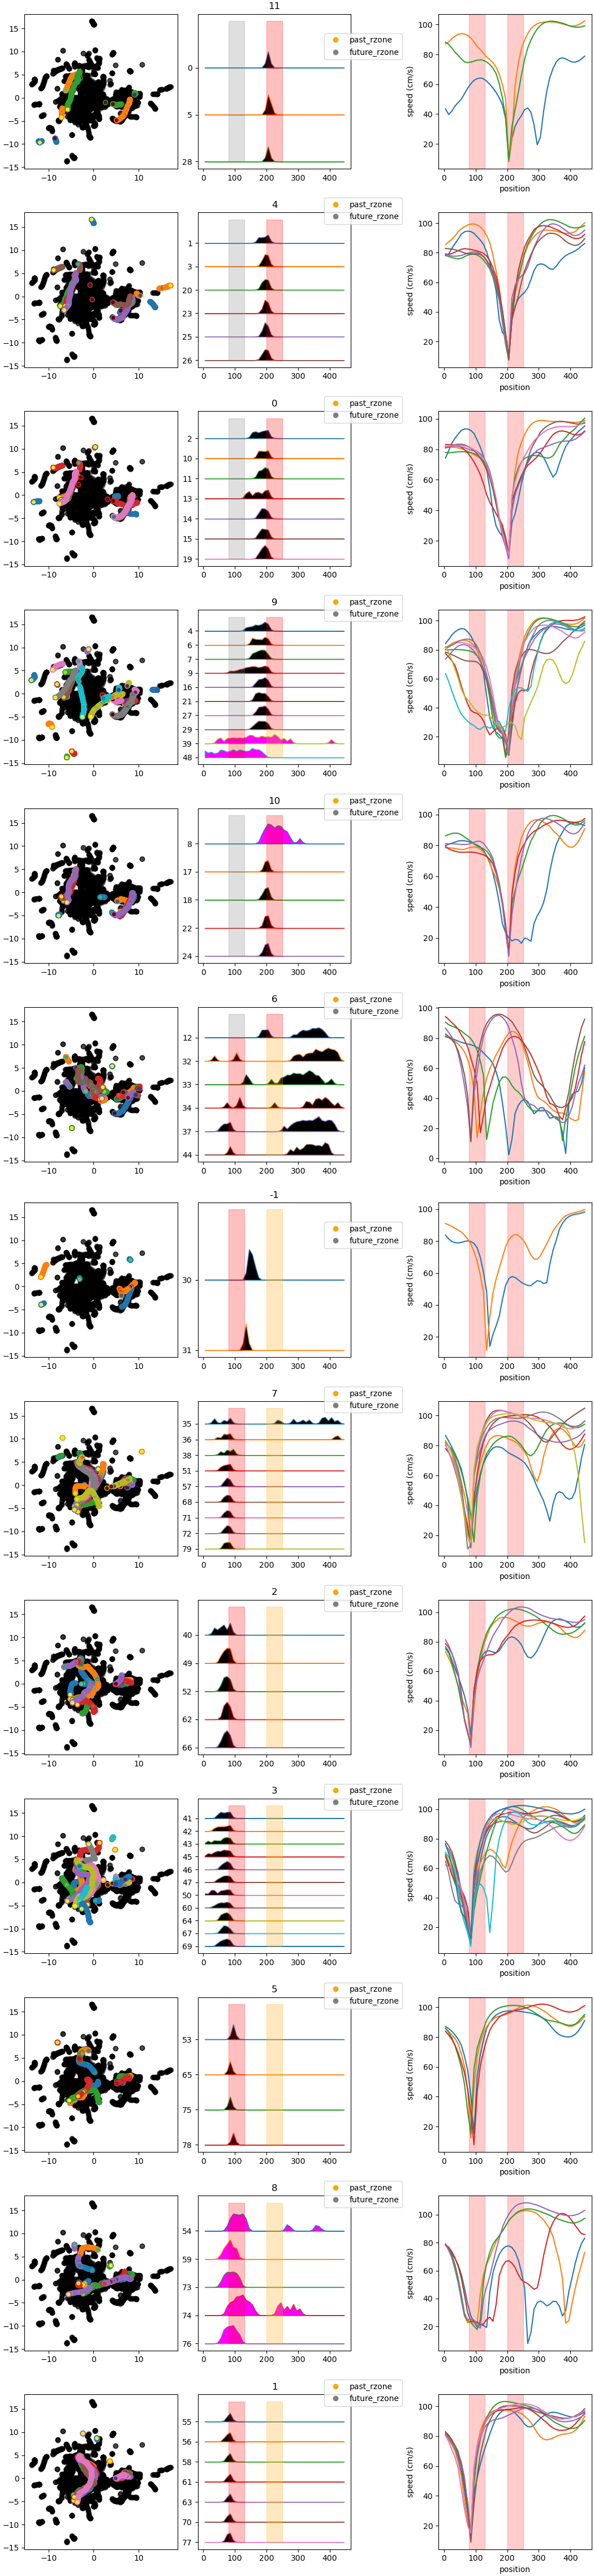

In [711]:

fig = plot_neural_embeddings_with_lick_clusters(animal_day_group['umap_embedding'], licks, trial_df, neural_bins, speeds)
fig.savefig(f'{animal}_{day}_licks_from_saved_embeddings_{animal}_{day}.svg')

In [712]:
f[animal][day]['neural_events_trial_matrix']

<HDF5 dataset "neural_events_trial_matrix": shape (80, 450, 611), type "<f8">

In [713]:
all_file = '/data/dave/sosa_data_h5/all_data'
f_all = h5py.File(all_file, "r") 

# animal = 'GCAMP14'
# day = '5'

In [714]:
events = f_all[animal][day]['timeseries']['events'][:].T



In [715]:
sum(np.isnan(events).all(axis = 1))

5285

In [716]:
f_all[animal][day]['vr_data']

<HDF5 group "/GCAMP14/12/vr_data" (18 members)>

In [717]:
vr_dat = pf.recreate_trial_meta_df(f_all[animal][day]['vr_data'])

In [718]:
sum(vr_dat.trialnum == -1)

134

In [719]:
events_na_free = events[(np.logical_not(np.isnan(events).all(axis = 1)))&(vr_dat.trialnum != -1)]
reducer = umap.UMAP(n_neighbors=int(150), min_dist=0.1)
            
embedding = reducer.fit_transform(events_na_free)

In [720]:
vr_dat_na_free = vr_dat.loc[(np.logical_not(np.isnan(events).all(axis = 1)))&(vr_dat.trialnum != -1)]

In [721]:
position = vr_dat_na_free.pos

In [722]:
"""
####### !!!!!!!!!!!!!!!!!!! MINIMALLY REVIEWED CLAUDE OUTPUT !!!!!!!!!!!!!!! #####################3

Piecewise / segmented colormapping for 1D data.

A base colormap spans [vmin, vmax]. Optional sub-ranges override that mapping,
each with either its own colormap (rescaled to that sub-range) or a flat color.
"""

import numpy as np
import matplotlib as mpl
from matplotlib.colors import Colormap, ListedColormap, Normalize, to_rgba


def _resolve_shade(spec):
    """Interpret a user spec as a Colormap or a single RGBA tuple.

    Colormap names win over CSS color names when both exist (e.g. 'pink',
    'gray', 'hot'). Pass an RGB(A) tuple to force a flat color.
    """
    if isinstance(spec, Colormap):
        return spec
    if isinstance(spec, str):
        if spec in mpl.colormaps:
            return mpl.colormaps[spec]
        return to_rgba(spec)
    return to_rgba(spec)


def _unit_scale(values, lo, hi):
    """Scale values to [0, 1] over [lo, hi]. NaNs pass through."""
    if hi == lo:
        return np.where(np.isnan(values), np.nan, 0.5)
    return (values - lo) / (hi - lo)


def _pair_zones(alternate_value_limits, alternate_cmaps):
    """Validate and zip zone limits with their color specs."""
    if alternate_value_limits is None:
        return []

    zones = [tuple(sorted(float(v) for v in pair))
             for pair in alternate_value_limits]

    if alternate_cmaps is None:
        raise ValueError("alternate_value_limits requires alternate_cmaps.")

    # A bare string, Colormap, or RGB(A) tuple is broadcast to every zone.
    is_scalar_spec = (
        isinstance(alternate_cmaps, (str, Colormap))
        or (isinstance(alternate_cmaps, tuple)
            and len(alternate_cmaps) in (3, 4)
            and all(isinstance(c, (int, float)) for c in alternate_cmaps))
    )
    specs = [alternate_cmaps] * len(zones) if is_scalar_spec else list(alternate_cmaps)

    if len(specs) != len(zones):
        raise ValueError(
            f"alternate_cmaps has {len(specs)} entries but "
            f"alternate_value_limits has {len(zones)}."
        )
    return list(zip(zones, specs))


def data_to_colors(data, cmap="viridis", vmin=None, vmax=None,
                   alternate_value_limits=None, alternate_cmaps=None):
    """Map values to RGBA using a base colormap plus overriding sub-ranges.

    Parameters
    ----------
    data : array-like of float or int
    cmap : str or Colormap
        Base colormap, normalized across [vmin, vmax].
    vmin, vmax : float, optional
        Defaults to the finite min/max of `data`.
    alternate_value_limits : sequence of (start, end), optional
        Value sub-ranges (inclusive) that get their own mapping.
    alternate_cmaps : sequence, str, Colormap, or RGB(A) tuple, optional
        Index-matched to `alternate_value_limits`. Each entry is either a
        colormap (rescaled to that zone's own limits) or a flat color.
        Later zones win where zones overlap.

    Returns
    -------
    (N, 4) float array of RGBA values. NaNs get the colormap's "bad" color.
    """
    values = np.asarray(data, dtype=float)
    vmin = np.nanmin(values) if vmin is None else float(vmin)
    vmax = np.nanmax(values) if vmax is None else float(vmax)

    base = _resolve_shade(cmap)
    if isinstance(base, Colormap):
        rgba = base(np.clip(_unit_scale(values, vmin, vmax), 0.0, 1.0))
    else:
        rgba = np.tile(base, (values.size, 1)).reshape(values.shape + (4,))

    for (lo, hi), spec in _pair_zones(alternate_value_limits, alternate_cmaps):
        mask = (values >= lo) & (values <= hi)
        if not mask.any():
            continue
        shade = _resolve_shade(spec)
        if isinstance(shade, Colormap):
            rgba[mask] = shade(np.clip(_unit_scale(values[mask], lo, hi), 0.0, 1.0))
        else:
            rgba[mask] = shade

    return rgba


def make_segmented_cmap(vmin, vmax, cmap="viridis", alternate_value_limits=None,
                        alternate_cmaps=None, n=1024, name="segmented"):
    """Bake the same mapping into a (ListedColormap, Normalize) pair.

    Use this when you need a real colormap object -- for `imshow`, `pcolormesh`,
    or a colorbar. Zone edges are quantized to n bins; raise n for sharp edges.
    """
    edges = np.linspace(vmin, vmax, n + 1)
    centers = 0.5 * (edges[:-1] + edges[1:])
    colors = data_to_colors(centers, cmap=cmap, vmin=vmin, vmax=vmax,
                            alternate_value_limits=alternate_value_limits,
                            alternate_cmaps=alternate_cmaps)
    return ListedColormap(colors, name=name), Normalize(vmin=vmin, vmax=vmax)

In [723]:
r_zones = pf.get_unique_reward_zones_from_meta(trial_df)

In [724]:


kw1 = dict(cmap = 'plasma', vmin=-50, vmax=456,
          alternate_value_limits=[[-51, 0], r_zones[0]],
          alternate_cmaps=['black','Reds_r'])

kw2 = dict(cmap = 'viridis', vmin=-50, vmax=456,
          alternate_value_limits=[[-51, 0], r_zones[1]],
          alternate_cmaps=['black','Reds_r'])


c1 = data_to_colors(position[vr_dat_na_free.trialnum<30],**kw1)
c2 = data_to_colors(position[vr_dat_na_free.trialnum>=30],**kw2)
c = np.concatenate((c1, c2))

seg_cmap, norm = make_segmented_cmap(kw1['vmin'], kw1['vmax'],
                                     **{k: v for k, v in kw1.items() if k not in ('vmin', 'vmax')})
seg_cmap2, norm2 = make_segmented_cmap(kw2['vmin'], kw2['vmax'],
                                     **{k: v for k, v in kw2.items() if k not in ('vmin', 'vmax')})



Text(0.5, 1.0, 'post swap')

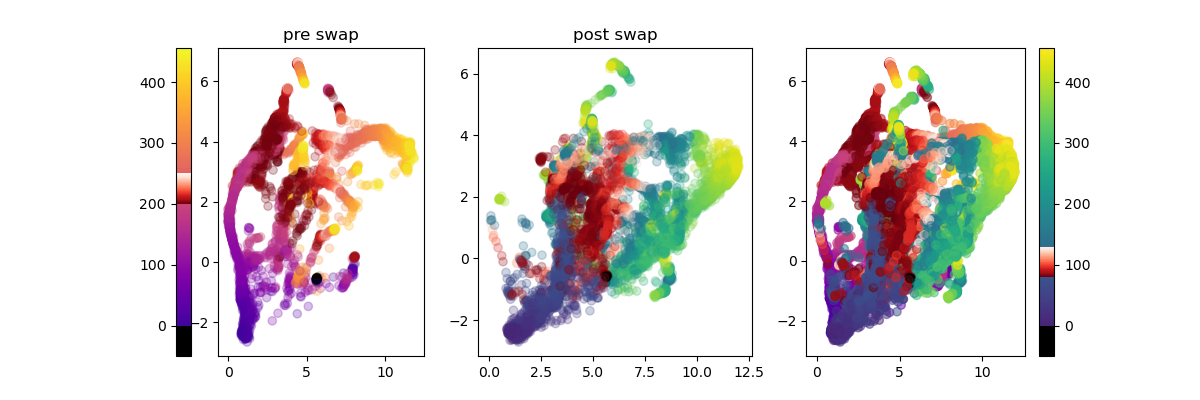

In [725]:
fig, axs = plt.subplots(ncols = 3, figsize = (12, 4))
axs[-1].scatter(embedding[:,0], embedding[:,1], c = c, alpha = 0.5)
axs[0].scatter(embedding[vr_dat_na_free.trialnum<30,0], embedding[vr_dat_na_free.trialnum<30,1], c = c1, alpha = 0.25)

axs[1].scatter(embedding[vr_dat_na_free.trialnum>=30,0], embedding[vr_dat_na_free.trialnum>=30,1], c = c2, alpha = 0.25)




fig.colorbar(ScalarMappable(norm=norm, cmap=seg_cmap), ax=axs[0], location = 'left', )
fig.colorbar(ScalarMappable(norm=norm2, cmap=seg_cmap2), ax=axs[-1], )
# fig.colorbar(ScalarMappable(norm=norm2, cmap=seg_cmap2), ax=axs[-1])
# fig.colorbar(ScalarMappable(norm=norm, cmap=seg_cmap), ax=axs[-1])

axs[0].set_title('pre swap')
axs[1].set_title('post swap')




In [726]:
vr_dat_na_free['hdb_labels'] = -1
for label in trial_df.hdb_labels.unique():
    trials = trial_df.loc[trial_df.hdb_labels == label].trial.values
    vr_dat_na_free.loc[vr_dat_na_free.trialnum.isin(trials).values, 'hdb_labels'] = label

/tmp/ipykernel_872863/3827585951.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  vr_dat_na_free['hdb_labels'] = -1


<Axes: >

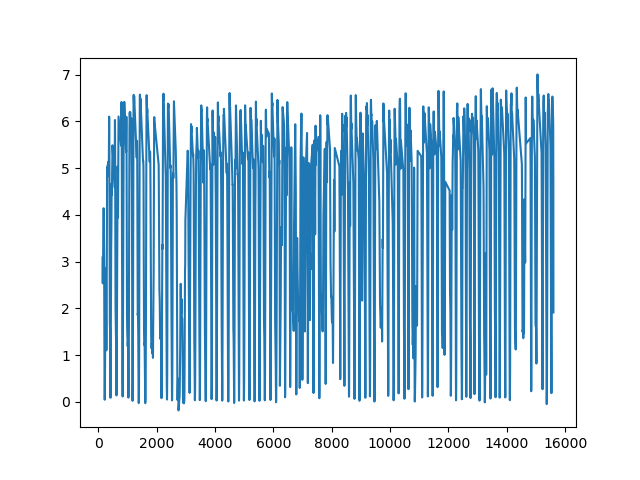

In [727]:
fig, ax =     plt.subplots()
vr_dat_na_free.dz.plot()

In [728]:
def plot_time_indexed_neural_embeddings_with_lick_clusters(neural_embedding, licks, labeled_meta, labeled_vr_meta, speed_bins = np.arange(5, 455, 10),
                                        cmap1_name = 'viridis', cmap2_name = None, trial_list = None):



    n_labels = len(labeled_vr_meta.hdb_labels.unique())

    r_zones = pf.get_unique_reward_zones_from_meta(labeled_meta)


    kw1 = dict(cmap = cmap1_name, vmin=-50, vmax=456,
          alternate_value_limits=[[-51, 0], r_zones[0]],
          alternate_cmaps=['black','Reds_r'])
    if cmap2_name is None:
        cmap2_name = cmap1_name
    kw2 = dict(cmap = 'viridis', vmin=-50, vmax=456,
            alternate_value_limits=[[-51, 0], r_zones[1]],
            alternate_cmaps=['black','Reds_r'])


    


    trial_cmap = sns.color_palette("tab10", as_cmap = True)
    if trial_list is None:
        fig, axs = plt.subplots(nrows = n_labels, ncols = 3, figsize = (3.5*3, 3.5*n_labels),layout="constrained")
        for i, label in enumerate(labeled_vr_meta.hdb_labels.unique()):
            print(label)
            label_meta = labeled_vr_meta.loc[labeled_vr_meta.hdb_labels == label]
            dat = neural_embedding[labeled_vr_meta.hdb_labels == label]
            dat_n = neural_embedding[labeled_vr_meta.hdb_labels != label]
            axs[i,0].scatter(dat_n[:,0], dat_n[:,1], alpha = 0.05, color = 'black')

            compare_idxs = labeled_meta.loc[(labeled_meta.hdb_labels==label), 'idx'].values
            compare_meta = labeled_meta.loc[(labeled_meta.hdb_labels==label)]

            compare_licks = pf.get_data_trials_by_idx(licks, labeled_meta, compare_idxs)


            linker = ppf.ColorLinker('trial')
            categorical_cmap = {unique:trial_cmap(i % trial_cmap.N) for i, unique in enumerate(compare_meta.trial.values)} #keep this to pass to other plot objects
            linker.set_categorical(categorical_cmap, 'trial')
            
            if len(compare_meta) == 1:
                compare_licks = [compare_licks]
            v = ppf.plot_raster_from_licks(compare_licks, 
                            compare_meta,ax = axs[i,1], edge_colorby = 'trial', edgecm = linker)


            c1 = data_to_colors(position[(labeled_vr_meta.hdb_labels == label)&(labeled_vr_meta.trialnum<30)],**kw1)
            c2 = data_to_colors(position[(labeled_vr_meta.hdb_labels == label)&(labeled_vr_meta.trialnum>=30)],**kw2)
            c = np.concatenate((c1, c2))
        
            seg_cmap, norm = make_segmented_cmap(kw1['vmin'], kw1['vmax'],
                                                **{k: v for k, v in kw1.items() if k not in ('vmin', 'vmax')})
            seg_cmap2, norm2 = make_segmented_cmap(kw2['vmin'], kw2['vmax'],
                                                **{k: v for k, v in kw2.items() if k not in ('vmin', 'vmax')})
            

            trial_colors = [trial_cmap(i % trial_cmap.N) for i, unique in enumerate(compare_meta.trial.values)]


            facecolors = np.zeros((len(dat), 4))
            speeds_from_label = []
            pos_from_label = []
            
            for color, trial in zip(trial_colors, label_meta.trialnum.unique()):

                facecolors[label_meta.trialnum == trial] = color
                speeds_from_label += [label_meta.loc[label_meta.trialnum == trial, 'dz'].values]
                pos_from_label += [label_meta.loc[label_meta.trialnum == trial, 'pos'].values]

            axs[i,0].scatter(dat[:,0], dat[:,1], facecolor= c, edgecolor = facecolors)

            

          

            for rzone in r_zones:
                    axs[i,-1].axvspan(xmin = rzone[0], xmax = rzone[1], color = 'red', alpha = 0.2)

            for j, trial in enumerate(zip(speeds_from_label, pos_from_label)):
                speed, pos = trial
            
                axs[i, -1].plot(pos, speed, color = trial_colors[j])

            axs[i,1].set_title(label)
            axs[i,-1].set_ylabel('speed (cm/s)')
            axs[i,-1].set_xlabel('position')

    return fig

In [729]:
vr_dat_na_free.hdb_labels.unique()

array([11,  4,  0,  9, 10,  6, -1,  7,  2,  3,  5,  8,  1])

11
4
0
9
10
6
-1
7
2
3
5
8
1


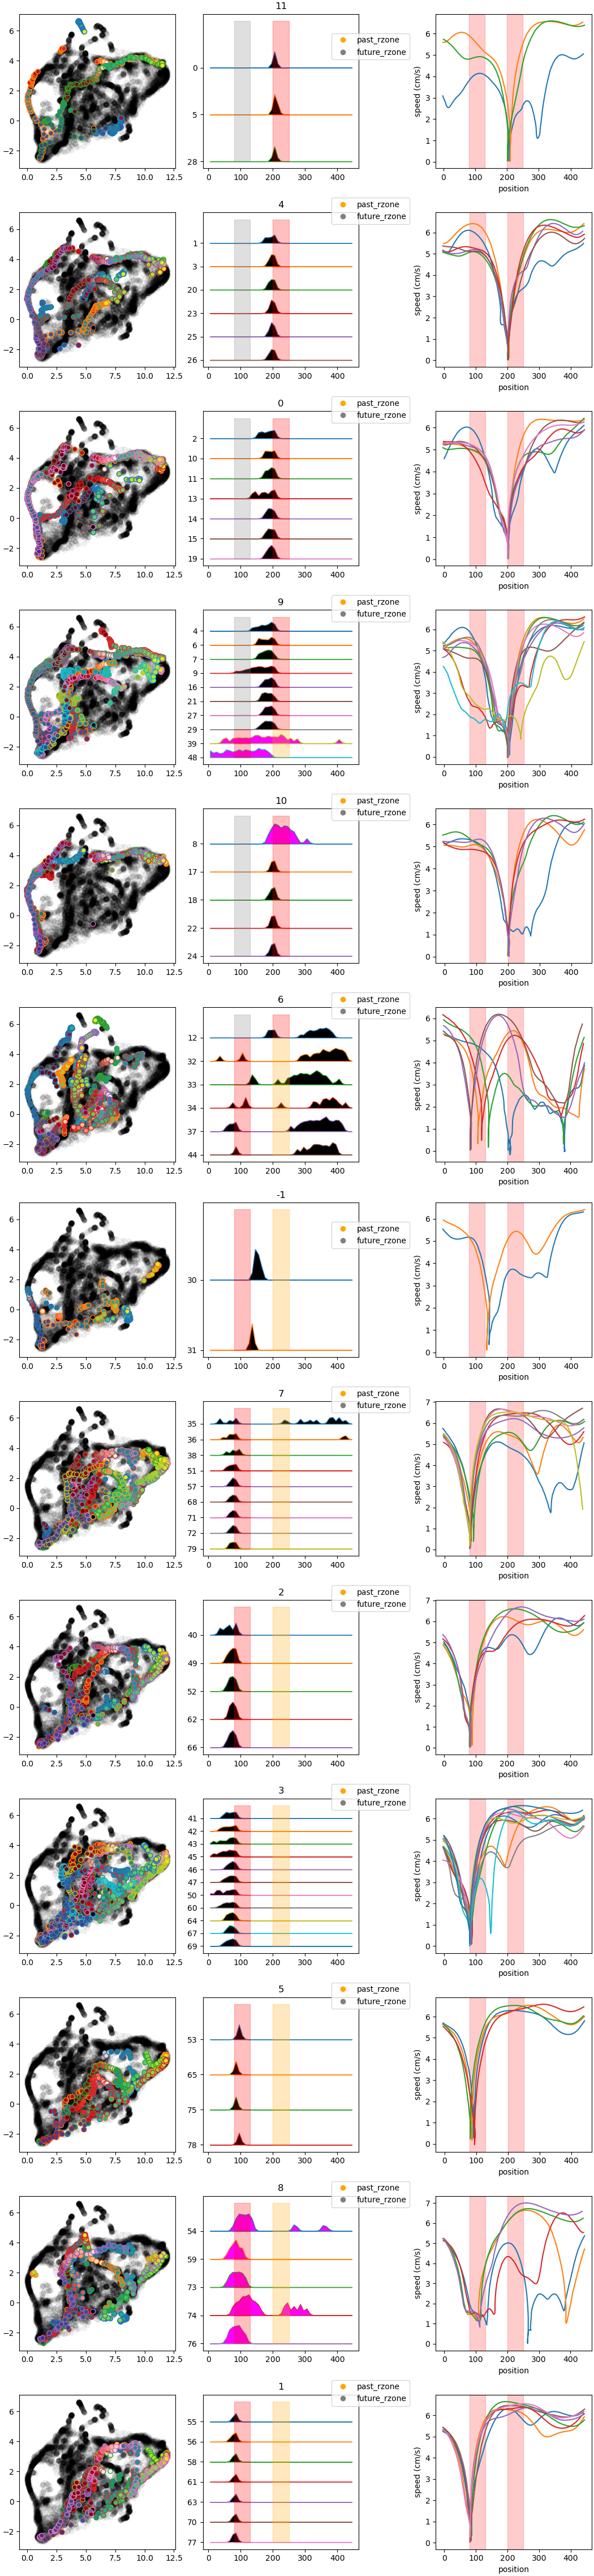

In [730]:
fig = plot_time_indexed_neural_embeddings_with_lick_clusters(embedding, licks, trial_df, labeled_vr_meta = vr_dat_na_free)

In [731]:
min_samples = 100
min_cluster_size = 100
new_labels = hdbscan.HDBSCAN(
    min_samples=min_samples,
    min_cluster_size=min_cluster_size,

).fit_predict(embedding)

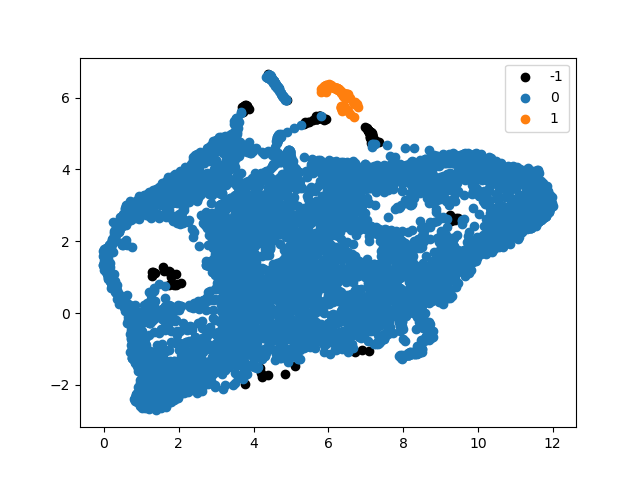

In [732]:
fig, ax = plt.subplots()
for label in np.unique(new_labels):
    if label == -1:
        
        ax.scatter(embedding[new_labels == label,0], 
                   embedding[new_labels == label,1], color = 'black', label = label)
    else:
        ax.scatter(embedding[new_labels == label,0], 
                           embedding[new_labels == label,1],  label = label)

ax.legend()